# Toxic Comments Classification - LR

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS


Dataset: JgsawToxic dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at Kaggle (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data). 


The comments are divided in two classes: toxic and normal.

Algorithme used: LR

Preprocessing techniques used:
* Lowercase
* Remove rare words
* Remove stop words
* Tokenization (accept all kind of tokens except spaces (carriage returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, cross_val_predict
from matplotlib import pyplot as plt 
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set2.csv')
df.head()

,Unnamed: 0,tweet,tox
0,12478,Just straight like that. No chaser. And the bi...,1
1,5791,@blowme you mean trash.,0
2,589,"""WHAAAAAAT! LMAOOO!!! @Cromotoasted: @creepgod...",1
3,18302,RT @Tylar____: Man this hoe Heaven stay taking...,1
4,8736,"Col. Sanders, Part 2: ""...and those sons of bi...",1


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set2.csv')
test.head()

,Unnamed: 0,tweet,tox
0,24082,auto tranny,0
1,10605,I get gwop now that bitch remember me,1
2,15645,RT @FunnyPicsDepot: Niggas develop superpowers...,1
3,6551,@kaylonnnnn then who are you to call me trash ...,0
4,14482,RT @AliAbunimah: The people of the ghetto are ...,0


# 3. Preprocessing

In [4]:
def clean_text(comment): 

    comment = comment.lower() # Normalize to lowercase 
        
    return comment

In [5]:
# clean and normalize comments
df['tweet'] = df['tweet'].map(lambda word:clean_text(word))
test['tweet'] = test['tweet'].map(lambda word:clean_text(word))

In [6]:
# find the 10 most frequent words in the train data
dellist1 = pd.Series(' '.join(df['tweet']).split()).value_counts(ascending=True)[1:10]
print(dellist1)

@victorgee97          1
shit&#8221;&#8221;    1
picky                 1
sosa"                 1
tunchi                1
&#128129;everybody    1
@shanequintero        1
@ikatrice:            1
@ladiesluv_audi:      1
dtype: int64


In [7]:
# remove the most frequent words from the train data
dellist1 = list(dellist1.index)
df['tweet'] = df['tweet'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist1))
df.head()

,Unnamed: 0,tweet,tox
0,12478,just straight like that. no chaser. and the bi...,1
1,5791,@blowme you mean trash.,0
2,589,"""whaaaaaat! lmaooo!!! @cromotoasted: @creepgod...",1
3,18302,rt @tylar____: man this hoe heaven stay taking...,1
4,8736,"col. sanders, part 2: ""...and those sons of bi...",1


In [8]:
# find the 10 most frequent words in the test data
dellist2 = pd.Series(' '.join(test['tweet']).split()).value_counts(ascending=True)[1:10]
print(dellist2)

hills!            1
@chill__cosby:    1
sin               1
tough-as-nails    1
europeans         1
ew                1
stache            1
ho's              1
nigra             1
dtype: int64


In [9]:
# remove the most frequent words from the test data
dellist2 = list(dellist2.index)
test['tweet'] = test['tweet'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist2))
test.head()

,Unnamed: 0,tweet,tox
0,24082,auto tranny,0
1,10605,i get gwop now that bitch remember me,1
2,15645,rt @funnypicsdepot: niggas develop superpowers...,1
3,6551,@kaylonnnnn then who are you to call me trash ...,0
4,14482,rt @aliabunimah: the people of the ghetto are ...,0


In [10]:
stop_words = set(stopwords.words('english'))

In [11]:
print(stop_words)

{'is', 'into', 'down', 'm', 'weren', 'who', 'couldn', 'our', "hadn't", 'they', 'and', 'your', "aren't", 'him', 'most', 'o', 'on', 'yourselves', 'his', 'didn', 'theirs', "she's", 'she', 'again', 'very', 'against', 'any', 'there', 'so', 't', "you're", 'am', 'will', 'some', 'ma', 'mightn', "weren't", "should've", 'few', 'if', 'above', 'out', 'with', 'won', 'both', 'than', "mightn't", 'ourselves', 'hasn', 'same', 'no', 'their', 'were', 'or', 'the', 'up', "wouldn't", 'did', "hasn't", 'do', 'only', 'here', 'once', 'doing', "that'll", "isn't", 'being', "shan't", 'other', 'after', 'under', 'nor', 'wouldn', 'because', 'shouldn', 'not', 'what', 'had', 'through', 'yours', "don't", 'at', 's', "doesn't", 'my', 'below', 'been', 'should', 'just', 'you', 'needn', "you'll", 've', 'ours', 'its', 'hadn', 'himself', 'how', 'whom', 'are', "you'd", 'doesn', 'each', 'while', 'then', 'll', 'has', 'haven', 'between', "needn't", 'of', 'those', "it's", 'this', 'wasn', 'when', 'was', "mustn't", 'over', 'before', 

In [12]:
def remove_stop_words(comment): 

    word_tokens = comment.split(' ') #word_tokenize(comment)
    
    filtered_comment = []  
    # converts the words in word_tokens tand tchecks whether 
    #they are present in stop_words or not
    for w in word_tokens:
        if w not in stop_words:
            filtered_comment.append(w)

    comment = (" ").join(filtered_comment)
    
    return comment

In [13]:
# clean and normalize comments
df['tweet'] = df['tweet'].map(lambda word:remove_stop_words(word))
test['tweet'] = test['tweet'].map(lambda word:remove_stop_words(word))

In [14]:
x_train = df['tweet']
y_train = df['tox']

#Check shape of data
print(x_train.shape)
print(y_train.shape)

(26521,)
(26521,)


In [15]:
X_test = test['tweet']
Y_test = test['tox']

#Check shape of data
print(X_test.shape)
print(Y_test.shape)

(6631,)
(6631,)


# 3. Classifier training (LR)

### Create pipeline

In [16]:
# create a pipeline
model_pipeline = Pipeline([
                ('tfidf', TfidfVectorizer(lowercase=False, 
                                          token_pattern=r'\S+', max_features=20000)),
                ('clf', LogisticRegression(max_iter=1000, random_state=0, verbose=True, C=10,
                                           class_weight='balanced', penalty='l1', solver='saga'))])

In [17]:
# cross validation
metrics = ['accuracy', 'recall', 'f1', 'precision']
result = cross_validate (model_pipeline, x_train, y_train, cv=5, scoring = metrics,  return_estimator=True)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 637 epochs took 511 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  8.5min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 687 epochs took 545 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  9.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  6.8min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 916 epochs took 507 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  8.4min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 592 epochs took 294 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  4.9min finished


In [18]:
# save models
svc_fit = result['estimator']
i = 0
for model in svc_fit:
    dir_name = "models/Set1_approach#16_" + str(i) + ".sav"
    pickle.dump(model, open(dir_name, 'wb'))
    i = i + 1

### Evaluate metrics

In [19]:
# Model Evaluation metrics for train data
train_accuracy = "%.4f" % (result['test_accuracy'].mean())
train_recall  = "%.4f" % (result['test_recall'].mean())
train_F1_score  = "%.4f" % (result['test_f1'].mean())
train_precision  = "%.4f" % (result['test_precision'].mean())

# Print scores for evaluation metrics
print('Results for train data')
print ('-----------------------')
print('Accuracy score : ', train_accuracy)
print('recall : ', train_recall)
print('F1_score : ' , train_F1_score)
print('precision : ' , train_precision)

Results for train data
-----------------------
Accuracy score :  0.9624
recall :  0.9290
F1_score :  0.9610
precision :  0.9954


# 4. Predictions

### Test set

In [20]:
# predict test data
preds_test = cross_val_predict(model_pipeline, X_test, Y_test, cv=5)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


max_iter reached after 68 seconds


/home/laboratoire/.pyenv/versions/3.7.8/envs/labo/lib/python3.7/site-packages/sklearn/linear_model/_sag.py:354: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  ConvergenceWarning,
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 538 epochs took 44 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   44.4s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   38.3s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 584 epochs took 45 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   45.4s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 584 epochs took 48 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   48.0s finished


In [21]:
# svm Confusion matrix
print('\n confusion matrix for test data \n')
print((confusion_matrix(Y_test, preds_test)))


 confusion matrix for test data 

[[3241  112]
 [ 354 2924]]


In [22]:
# svm classification report
print('\n\n classification report for test data \n')
print(classification_report(Y_test, preds_test, target_names=['normal','toxic']))



 classification report for test data 

              precision    recall  f1-score   support

      normal       0.90      0.97      0.93      3353
       toxic       0.96      0.89      0.93      3278

    accuracy                           0.93      6631
   macro avg       0.93      0.93      0.93      6631
weighted avg       0.93      0.93      0.93      6631



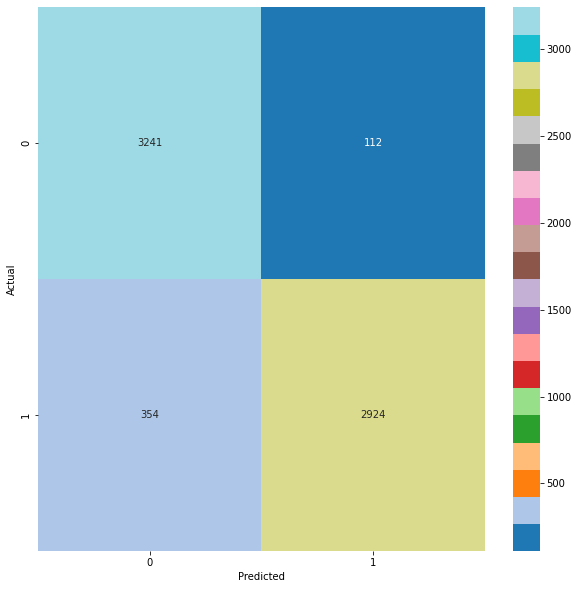

In [23]:
# plot confusion matrix
conf_mat = confusion_matrix(Y_test, preds_test)
fig, ax = plt.subplots(figsize=(10,10))
cmap = "tab20"
sns.heatmap(conf_mat, annot=True, fmt='d',cmap=cmap)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [24]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, preds_test))
test_recall  = "%.4f" % (recall_score(Y_test, preds_test))
test_F1_score  = "%.4f" % (f1_score(Y_test, preds_test))
test_precision  = "%.4f" % (precision_score(Y_test, preds_test))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.9297
recall :  0.8920
F1_score :  0.9262
precision :  0.9631


# 5. Save results to Excel file

In [25]:
# define tarjet
newFile = "../results_LR_set2.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #16', 2:train_accuracy, 3:train_recall, 4:train_F1_score, 5:train_precision, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach
index = 18

# delete row of approach
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)